In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

original_image = cv2.imread("TC_JR.jpg")
gray_image = cv2.imread("TC_JR.jpg", cv2.IMREAD_GRAYSCALE)

### 7.1

In [2]:
bilateral_filtered_image = cv2.bilateralFilter(gray_image, 9, 75, 75)
gaussian_filtered_image = cv2.GaussianBlur(gray_image, (5, 5), 0)
median_filtered_image = cv2.medianBlur(gray_image, 5)

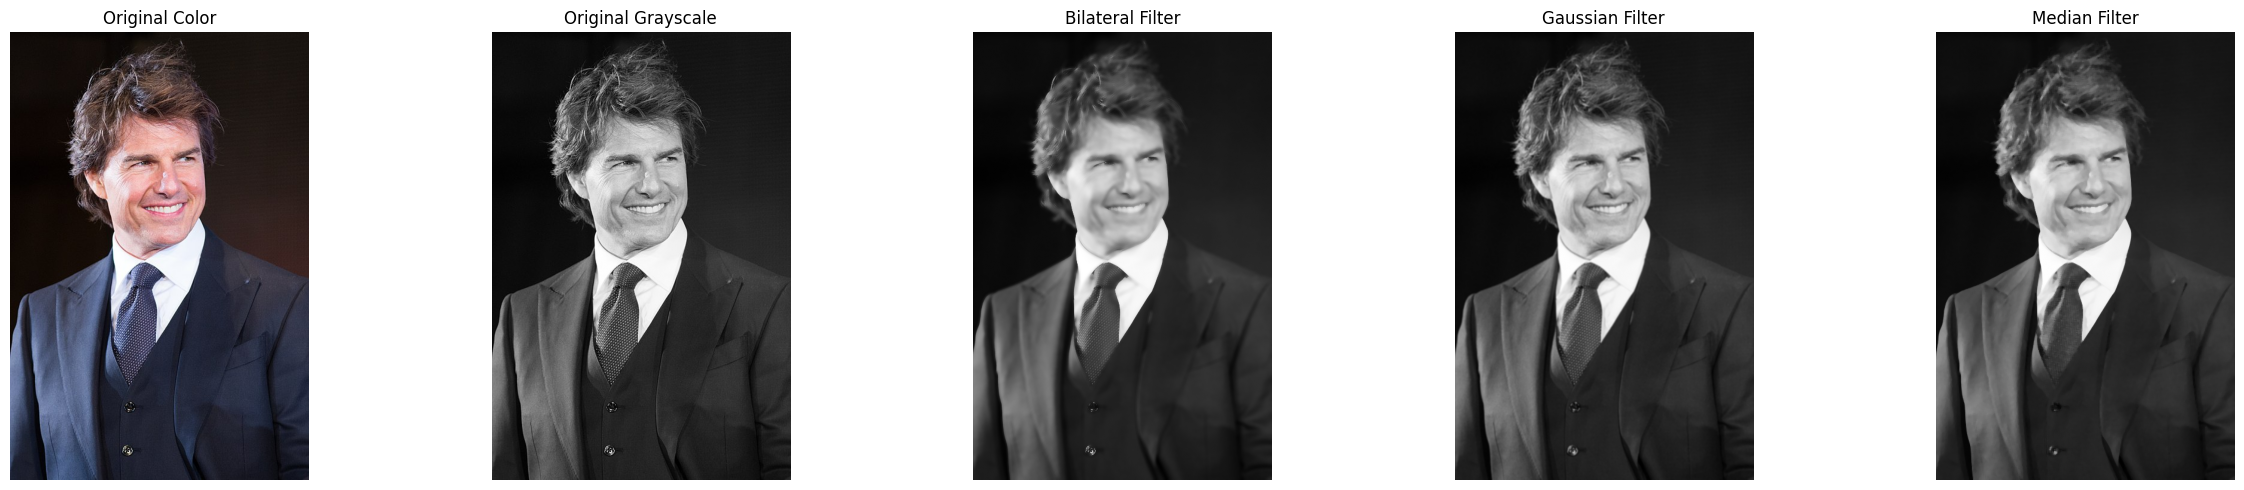

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

axes[0].imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original Color")
axes[0].axis("off")

axes[1].imshow(gray_image, cmap="gray")
axes[1].set_title("Original Grayscale")
axes[1].axis("off")

axes[2].imshow(bilateral_filtered_image, cmap="gray")
axes[2].set_title("Bilateral Filter")
axes[2].axis("off")

axes[3].imshow(gaussian_filtered_image, cmap="gray")
axes[3].set_title("Gaussian Filter")
axes[3].axis("off")

axes[4].imshow(median_filtered_image, cmap="gray")
axes[4].set_title("Median Filter")
axes[4].axis("off")

plt.tight_layout()
plt.show()

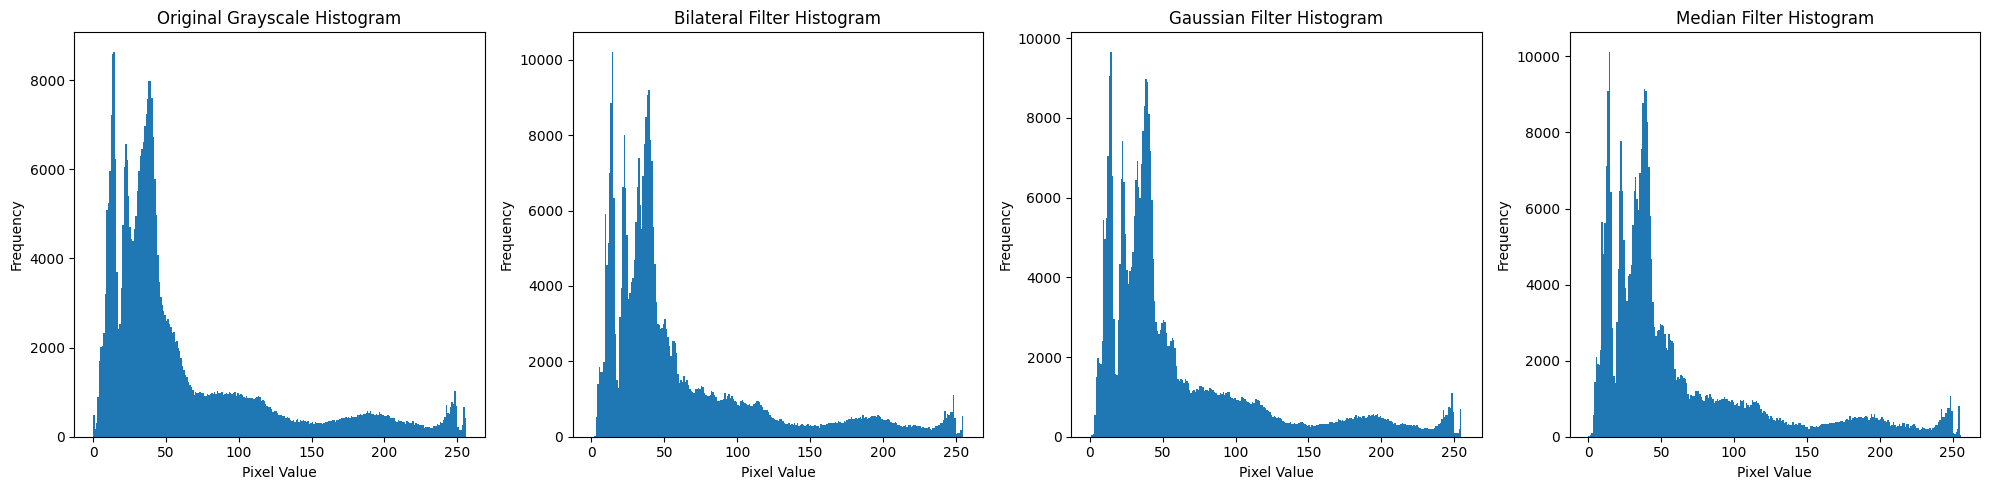

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].hist(gray_image.ravel(), 256, range=[0, 256])
axes[0].set_title("Original Grayscale Histogram")
axes[0].set_xlabel("Pixel Value")
axes[0].set_ylabel("Frequency")

axes[1].hist(bilateral_filtered_image.ravel(), 256, range=[0, 256])
axes[1].set_title("Bilateral Filter Histogram")
axes[1].set_xlabel("Pixel Value")
axes[1].set_ylabel("Frequency")

axes[2].hist(gaussian_filtered_image.ravel(), 256, range=[0, 256])
axes[2].set_title("Gaussian Filter Histogram")
axes[2].set_xlabel("Pixel Value")
axes[2].set_ylabel("Frequency")

axes[3].hist(median_filtered_image.ravel(), 256, range=[0, 256])
axes[3].set_title("Median Filter Histogram")
axes[3].set_xlabel("Pixel Value")
axes[3].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### 7.2

In [5]:
kernel = np.ones((5, 5), np.uint8)
erosion = cv2.erode(gray_image, kernel, iterations=1)
dilation = cv2.dilate(gray_image, kernel, iterations=1)
opening = cv2.morphologyEx(gray_image, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(gray_image, cv2.MORPH_CLOSE, kernel)

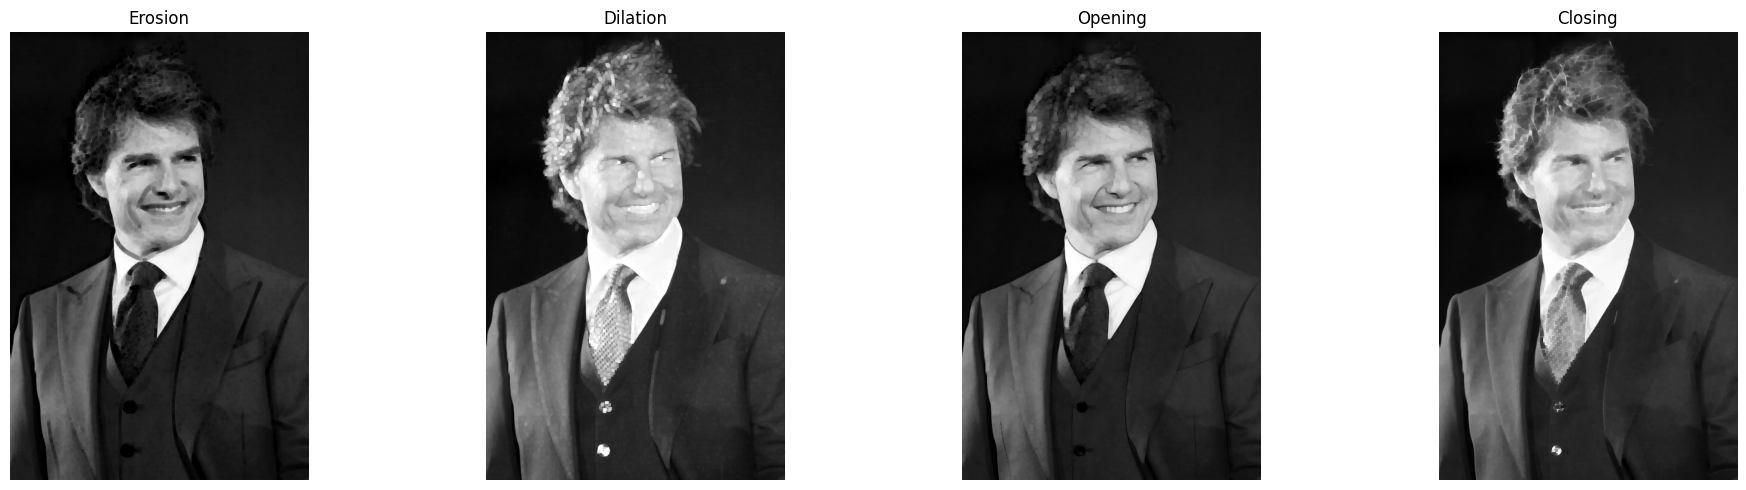

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(erosion, cmap="gray")
axes[0].set_title("Erosion")
axes[0].axis("off")

axes[1].imshow(dilation, cmap="gray")
axes[1].set_title("Dilation")
axes[1].axis("off")

axes[2].imshow(opening, cmap="gray")
axes[2].set_title("Opening")
axes[2].axis("off")

axes[3].imshow(closing, cmap="gray")
axes[3].set_title("Closing")
axes[3].axis("off")

plt.tight_layout()
plt.show()

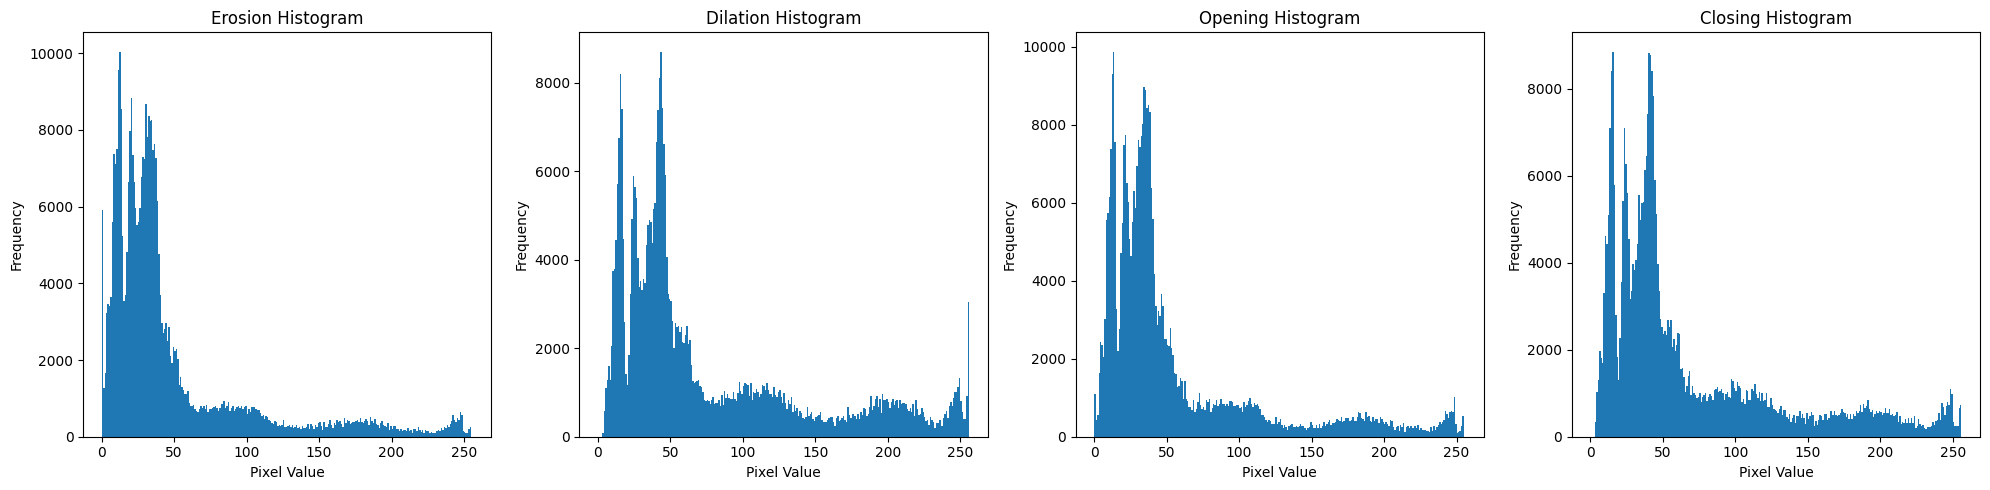

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].hist(erosion.ravel(), 256, range=[0, 256])
axes[0].set_title("Erosion Histogram")
axes[0].set_xlabel("Pixel Value")
axes[0].set_ylabel("Frequency")

axes[1].hist(dilation.ravel(), 256, range=[0, 256])
axes[1].set_title("Dilation Histogram")
axes[1].set_xlabel("Pixel Value")
axes[1].set_ylabel("Frequency")

axes[2].hist(opening.ravel(), 256, range=[0, 256])
axes[2].set_title("Opening Histogram")
axes[2].set_xlabel("Pixel Value")
axes[2].set_ylabel("Frequency")

axes[3].hist(closing.ravel(), 256, range=[0, 256])
axes[3].set_title("Closing Histogram")
axes[3].set_xlabel("Pixel Value")
axes[3].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### 7.3

In [8]:
img2 = original_image.copy()

blend1 = cv2.addWeighted(original_image, 0.7, img2, 0.3, 0)
blend2 = cv2.addWeighted(original_image, 0.5, img2, 0.5, 0)

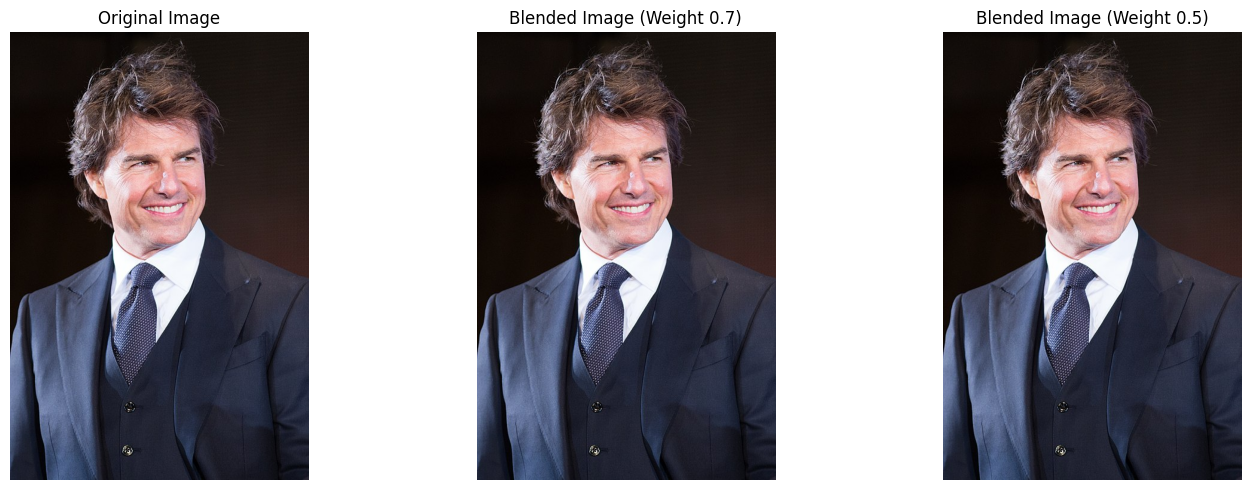

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(blend1, cv2.COLOR_BGR2RGB))
axes[1].set_title("Blended Image (Weight 0.7)")
axes[1].axis("off")

axes[2].imshow(cv2.cvtColor(blend2, cv2.COLOR_BGR2RGB))
axes[2].set_title("Blended Image (Weight 0.5)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

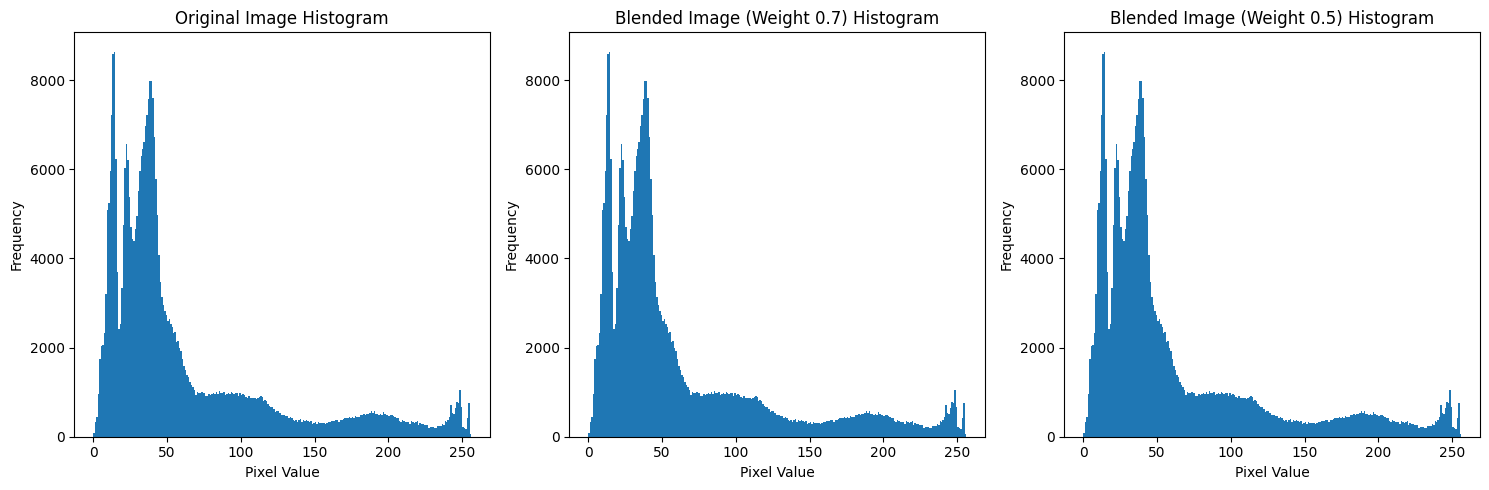

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(
    cv2.cvtColor(original_image, cv2.COLOR_BGR2GRAY).ravel(), 256, range=[0, 256]
)
axes[0].set_title("Original Image Histogram")
axes[0].set_xlabel("Pixel Value")
axes[0].set_ylabel("Frequency")

axes[1].hist(cv2.cvtColor(blend1, cv2.COLOR_BGR2GRAY).ravel(), 256, range=[0, 256])
axes[1].set_title("Blended Image (Weight 0.7) Histogram")
axes[1].set_xlabel("Pixel Value")
axes[1].set_ylabel("Frequency")

axes[2].hist(cv2.cvtColor(blend2, cv2.COLOR_BGR2GRAY).ravel(), 256, range=[0, 256])
axes[2].set_title("Blended Image (Weight 0.5) Histogram")
axes[2].set_xlabel("Pixel Value")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### 7.4

In [11]:
f = np.fft.fft2(gray_image)
fshift = np.fft.fftshift(f)

rows, cols = gray_image.shape
crow, ccol = rows // 2, cols // 2

r = 30  # or any integer value suitable for your image size

mask = np.zeros((rows, cols), np.uint8)
cv2.circle(mask, (ccol, crow), r, 1, -1)

fshift_low = fshift * mask
f_ishift_low = np.fft.ifftshift(fshift_low)

img_low = np.abs(np.fft.ifft2(f_ishift_low))

mask_high = 1 - mask

fshift_high = fshift * mask_high
f_ishift_high = np.fft.ifftshift(fshift_high)

img_high = np.abs(np.fft.ifft2(f_ishift_high))

In [12]:
gaussian_blur = cv2.GaussianBlur(gray_image, (9, 9), 10)
unsharp = cv2.addWeighted(gray_image, 1.5, gaussian_blur, -0.5, 0)

# Laplacian sharpening
laplacian = cv2.Laplacian(gray_image, cv2.CV_64F)
laplacian_sharp = cv2.convertScaleAbs(gray_image + laplacian)

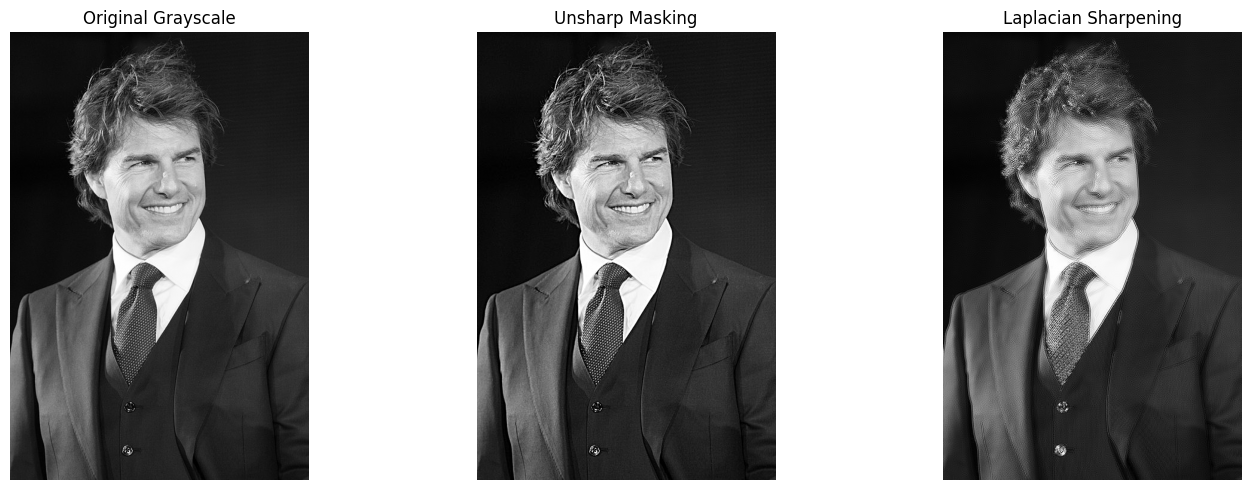

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(gray_image, cmap="gray")
axes[0].set_title("Original Grayscale")
axes[0].axis("off")


axes[1].imshow(unsharp, cmap="gray")
axes[1].set_title("Unsharp Masking")
axes[1].axis("off")

axes[2].imshow(laplacian_sharp, cmap="gray")
axes[2].set_title("Laplacian Sharpening")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### 7.5

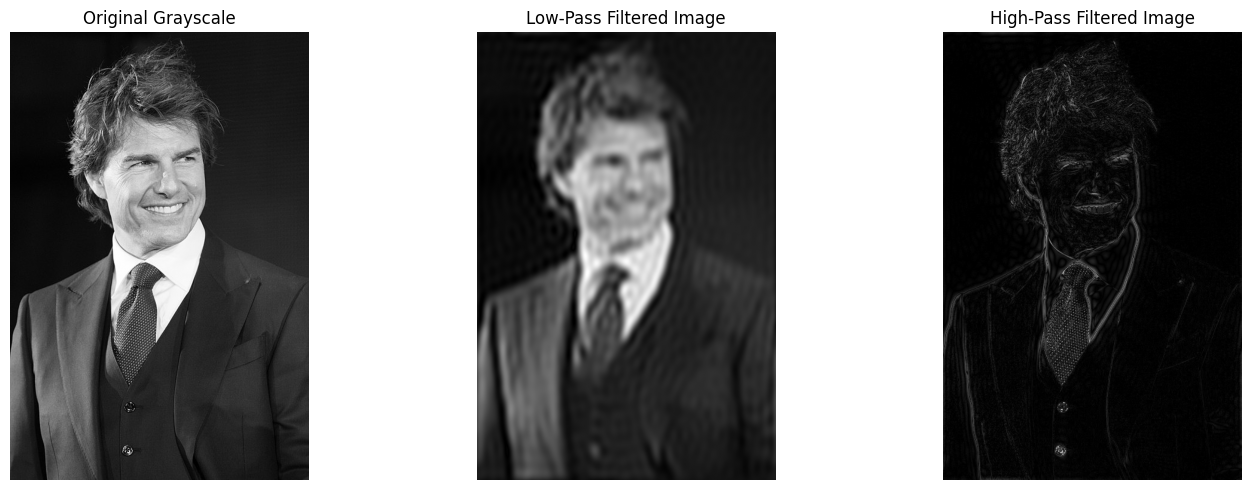

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(gray_image, cmap="gray")
axes[0].set_title("Original Grayscale")
axes[0].axis("off")

axes[1].imshow(img_low, cmap="gray")
axes[1].set_title("Low-Pass Filtered Image")
axes[1].axis("off")

axes[2].imshow(img_high, cmap="gray")
axes[2].set_title("High-Pass Filtered Image")
axes[2].axis("off")

plt.tight_layout()
plt.show()

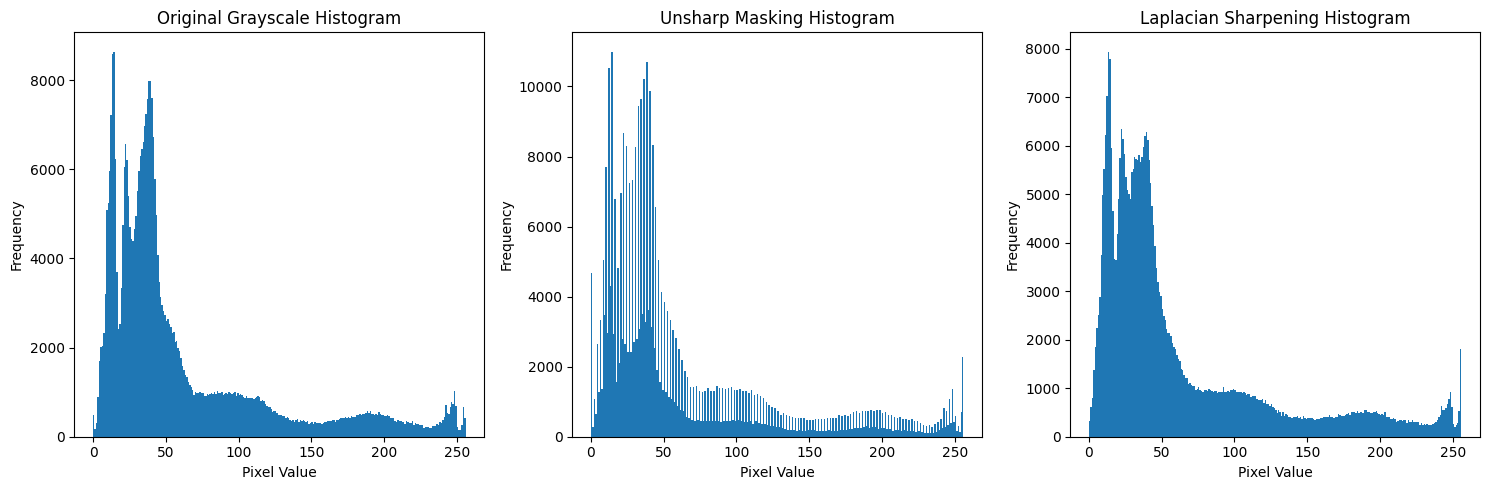

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(gray_image.ravel(), 256, range=[0, 256])
axes[0].set_title("Original Grayscale Histogram")
axes[0].set_xlabel("Pixel Value")
axes[0].set_ylabel("Frequency")

axes[1].hist(unsharp.ravel(), 256, range=[0, 256])
axes[1].set_title("Unsharp Masking Histogram")
axes[1].set_xlabel("Pixel Value")
axes[1].set_ylabel("Frequency")

axes[2].hist(laplacian_sharp.ravel(), 256, range=[0, 256])
axes[2].set_title("Laplacian Sharpening Histogram")
axes[2].set_xlabel("Pixel Value")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### 7.6

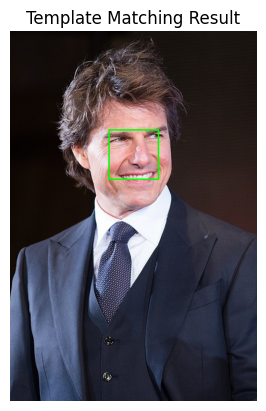

In [16]:
img_with_match = original_image.copy()
template = gray_image[200:300, 200:300]

res = cv2.matchTemplate(gray_image, template, cv2.TM_CCOEFF_NORMED)
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)
h, w = template.shape

cv2.rectangle(img_with_match, max_loc, (max_loc[0] + w, max_loc[1] + h), (0, 255, 0), 2)

plt.imshow(cv2.cvtColor(img_with_match, cv2.COLOR_BGR2RGB))
plt.title("Template Matching Result")
plt.axis("off")
plt.show()

### 7.7

In [17]:
hsv = cv2.cvtColor(original_image, cv2.COLOR_BGR2HSV)
lab = cv2.cvtColor(original_image, cv2.COLOR_BGR2LAB)

hsv[:, :, 2] = cv2.add(hsv[:, :, 2], 50)
lab[:, :, 0] = cv2.add(lab[:, :, 0], 50)

img_hsv_bright = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
img_lab_bright = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

img_rgb_bright = cv2.add(original_image, (50, 50, 50, 0))

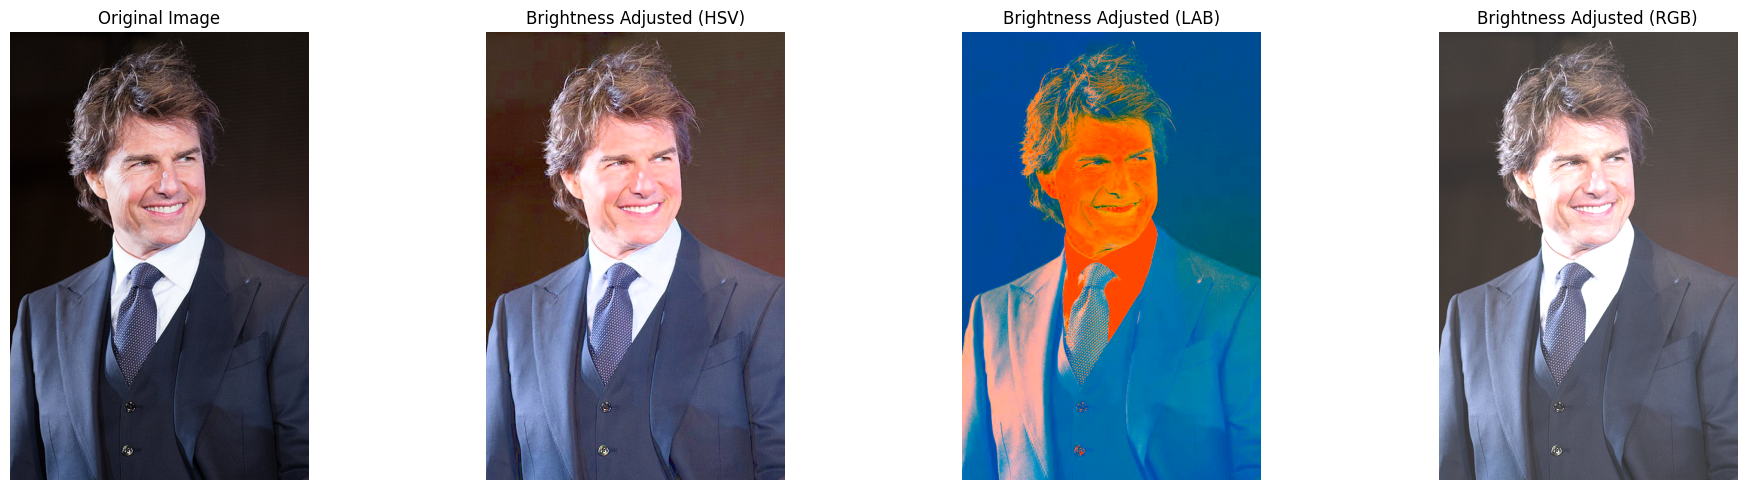

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(img_hsv_bright, cv2.COLOR_BGR2RGB))
axes[1].set_title("Brightness Adjusted (HSV)")
axes[1].axis("off")

axes[2].imshow(cv2.cvtColor(img_lab_bright, cv2.COLOR_LAB2RGB))
axes[2].set_title("Brightness Adjusted (LAB)")
axes[2].axis("off")

axes[3].imshow(cv2.cvtColor(img_rgb_bright, cv2.COLOR_BGR2RGB))
axes[3].set_title("Brightness Adjusted (RGB)")
axes[3].axis("off")

plt.tight_layout()
plt.show()

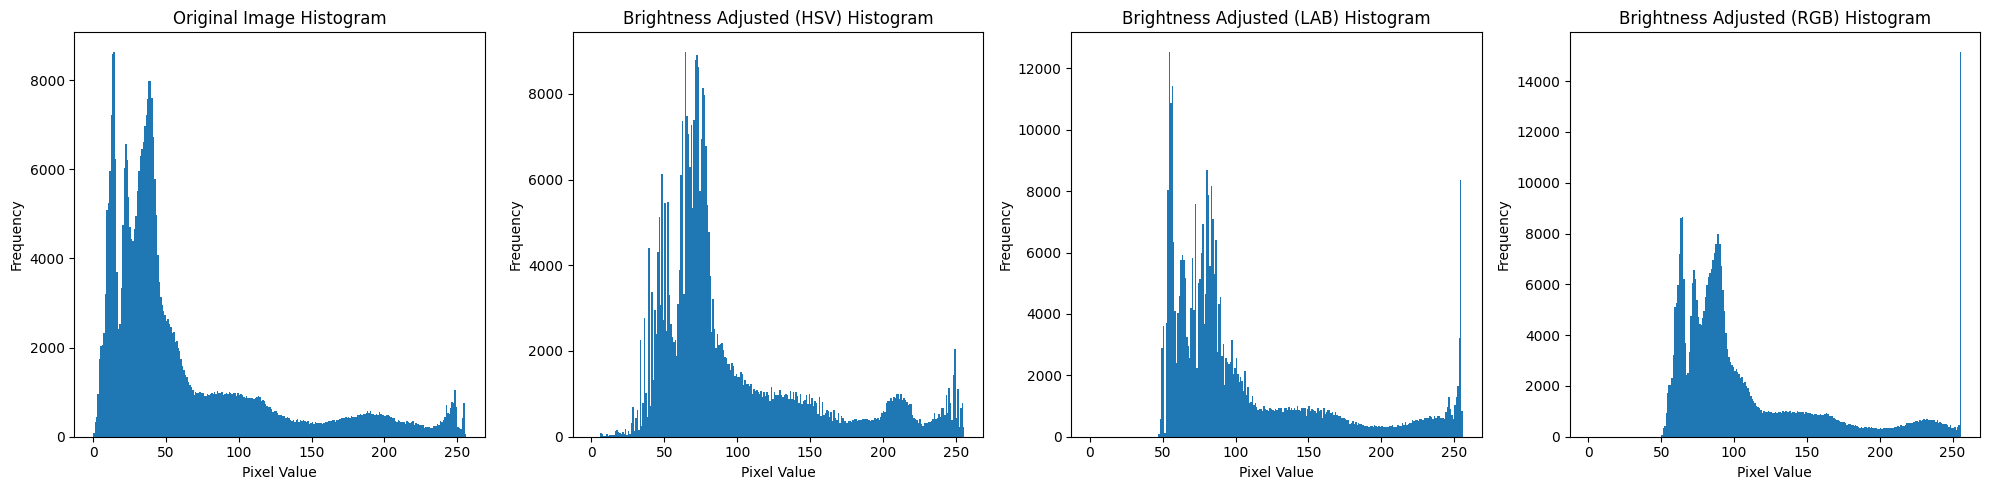

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].hist(
    cv2.cvtColor(original_image, cv2.COLOR_BGR2GRAY).ravel(), 256, range=[0, 256]
)
axes[0].set_title("Original Image Histogram")
axes[0].set_xlabel("Pixel Value")
axes[0].set_ylabel("Frequency")

axes[1].hist(
    cv2.cvtColor(img_hsv_bright, cv2.COLOR_BGR2GRAY).ravel(), 256, range=[0, 256]
)
axes[1].set_title("Brightness Adjusted (HSV) Histogram")
axes[1].set_xlabel("Pixel Value")
axes[1].set_ylabel("Frequency")

axes[2].hist(
    cv2.cvtColor(img_lab_bright, cv2.COLOR_BGR2GRAY).ravel(), 256, range=[0, 256]
)
axes[2].set_title("Brightness Adjusted (LAB) Histogram")
axes[2].set_xlabel("Pixel Value")
axes[2].set_ylabel("Frequency")

axes[3].hist(
    cv2.cvtColor(img_rgb_bright, cv2.COLOR_BGR2GRAY).ravel(), 256, range=[0, 256]
)
axes[3].set_title("Brightness Adjusted (RGB) Histogram")
axes[3].set_xlabel("Pixel Value")
axes[3].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### 7.8

In [20]:
def gamma_correction(image, gamma):
    # Normalize to [0,1], apply power, then rescale to [0,255]
    corrected = np.power(image / 255.0, gamma) * 255
    return np.uint8(corrected)


gamma_0_5 = gamma_correction(original_image, 0.5)
gamma_1_0 = gamma_correction(original_image, 1.0)
gamma_2_0 = gamma_correction(original_image, 2.0)

### 7.9

In [21]:
sobel_x = cv2.Sobel(gray_image, cv2.CV_64F, 1, 0, ksize=5)
sobel_y = cv2.Sobel(gray_image, cv2.CV_64F, 0, 1, ksize=5)
sobel_combined = cv2.magnitude(sobel_x, sobel_y)
sobel_combined = cv2.convertScaleAbs(sobel_combined)

prewitt_kernel_x = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]])
prewitt_x = cv2.filter2D(gray_image, -1, prewitt_kernel_x)

prewitt_kernel_y = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]])
prewitt_y = cv2.filter2D(gray_image, -1, prewitt_kernel_y)

prewitt_combined = cv2.magnitude(
    prewitt_x.astype(np.float64), prewitt_y.astype(np.float64)
)
prewitt_combined = cv2.convertScaleAbs(prewitt_combined)

canny = cv2.Canny(gray_image, 100, 200)

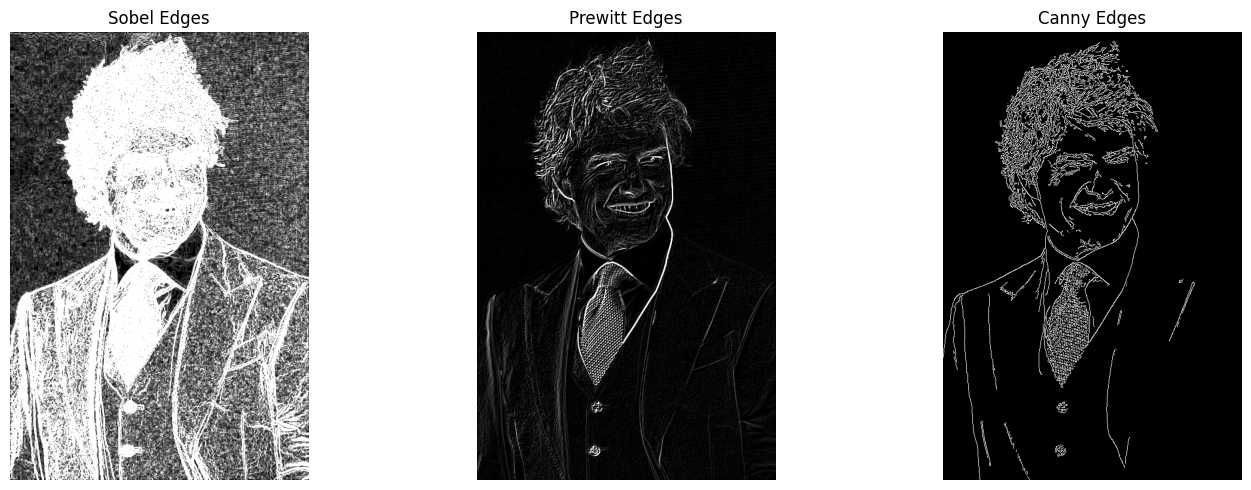

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(sobel_combined, cmap="gray")
axes[0].set_title("Sobel Edges")
axes[0].axis("off")

axes[1].imshow(prewitt_combined, cmap="gray")
axes[1].set_title("Prewitt Edges")
axes[1].axis("off")

axes[2].imshow(canny, cmap="gray")
axes[2].set_title("Canny Edges")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### 7.10

In [23]:
down = cv2.resize(original_image, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_LINEAR)
up = cv2.resize(
    down,
    (original_image.shape[1], original_image.shape[0]),
    interpolation=cv2.INTER_LINEAR,
)

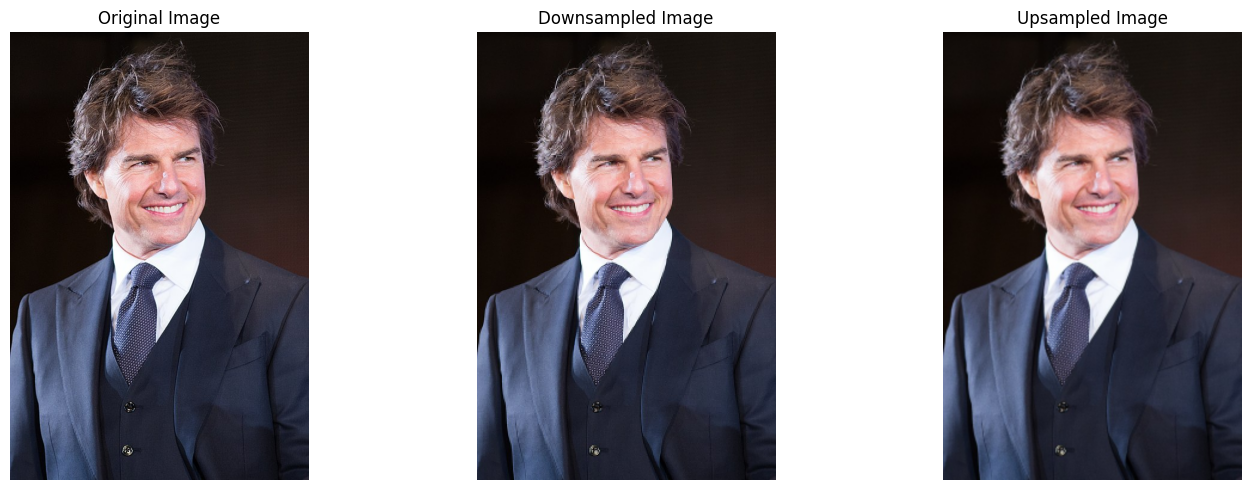

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(down, cv2.COLOR_BGR2RGB))
axes[1].set_title("Downsampled Image")
axes[1].axis("off")

axes[2].imshow(cv2.cvtColor(up, cv2.COLOR_BGR2RGB))
axes[2].set_title("Upsampled Image")
axes[2].axis("off")

plt.tight_layout()
plt.show()